In [117]:

#import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.base import clone


In [68]:
import pandas as pd

url = "https://www.kaggle.com/api/v1/datasets/download/syedanwarafridi/vehicle-sales-data"

df = pd.read_csv(url, compression="zip")

df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [69]:
df.head(10)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
5,2015,Nissan,Altima,2.5 S,Sedan,automatic,1n4al3ap1fn326013,ca,1.0,5554.0,gray,black,enterprise vehicle exchange / tra / rental / t...,15350.0,10900.0,Tue Dec 30 2014 12:00:00 GMT-0800 (PST)
6,2014,BMW,M5,Base,Sedan,automatic,wbsfv9c51ed593089,ca,34.0,14943.0,black,black,the hertz corporation,69000.0,65000.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST)
7,2014,Chevrolet,Cruze,1LT,Sedan,automatic,1g1pc5sb2e7128460,ca,2.0,28617.0,black,black,enterprise vehicle exchange / tra / rental / t...,11900.0,9800.0,Tue Dec 16 2014 13:00:00 GMT-0800 (PST)
8,2014,Audi,A4,2.0T Premium Plus quattro,Sedan,automatic,wauffafl3en030343,ca,42.0,9557.0,white,black,audi mission viejo,32100.0,32250.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST)
9,2014,Chevrolet,Camaro,LT,Convertible,automatic,2g1fb3d37e9218789,ca,3.0,4809.0,red,black,d/m auto sales inc,26300.0,17500.0,Tue Jan 20 2015 04:00:00 GMT-0800 (PST)


In [70]:
df.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,65352
vin,4
state,0
condition,11820
odometer,94


In [71]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [72]:
df.isnull().sum() / len(df) * 100

,0
year,0.000000
make,1.843292
model,1.860829
trim,1.905922
body,2.361154
transmission,11.694287
vin,0.000716
state,0.000000
condition,2.115107
odometer,0.016821


transmission column ins te only column with NaN values higher than 3%. it will be filled by regression and mode.  than the other NAN values in the colns are goind to be cleaned

In [139]:
df_mode = df.copy()

df_mode['transmission'] = df_mode['transmission'].fillna(
    df_mode['transmission'].mode()[0]
)
df_mode.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,0
vin,4
state,0
condition,11820
odometer,94


preparing data to fill transmission NA

In [126]:


filled = df.dropna()


filled.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [75]:
#separating columns
filled = filled[['make','year', 'trim', 'model', 'body','transmission']]
filled.head()

,make,year,trim,model,body,transmission
0,Kia,2015,LX,Sorento,SUV,automatic
1,Kia,2015,LX,Sorento,SUV,automatic
2,BMW,2014,328i SULEV,3 Series,Sedan,automatic
3,Volvo,2015,T5,S60,Sedan,automatic
4,BMW,2014,650i,6 Series Gran Coupe,Sedan,automatic


In [76]:
#encoding columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

filled['make'] = le.fit_transform(filled['make'])
filled['trim'] = le.fit_transform(filled['trim'])
filled['body'] = le.fit_transform(filled['body'])
filled['transmission'] = le.fit_transform(filled['transmission'])
filled['model'] = le.fit_transform(filled['model'])

filled.head()



,make,year,trim,model,body,transmission
0,24,2015,818,637,35,0
1,24,2015,818,637,35,0
2,3,2014,253,8,36,0
3,51,2015,1212,575,36,0
4,3,2014,335,33,36,0


In [77]:
filled.nunique()

,0
make,53
year,26
trim,1494
model,768
body,85
transmission,2


there are 53 makers, 786 models, 1494 trim, 85 body, 2 transmissions, distributed in 26 years

In [78]:
xt_train, xt_test, yt_train, yt_test = train_test_split(filled.drop('transmission', axis=1), filled['transmission'], test_size=0.2, random_state=42)

it was chosen the random split due to the fact that year and sell dat migth impact the sell price

In [79]:
yt_test.head()

,transmission
297590,0
90053,0
341051,0
362239,0
480321,0


In [80]:
model_t = LogisticRegression()
model_t.fit(xt_train, yt_train)

pred_t = model_t.predict(xt_test)

In [81]:
acc_t = accuracy_score(yt_test, pred_t)
print("Accuracy:", acc_t)

Accuracy: 0.9649499814746202


In [82]:
prec_t = precision_score(yt_test, pred_t)
print("Precision:", prec_t)

Precision: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [83]:
filled.nunique()

,0
make,53
year,26
trim,1494
model,768
body,85
transmission,2


my model predicted only 0, it was due to the fact the data is umbalanced, before to optmize it, i will cher the data vizually


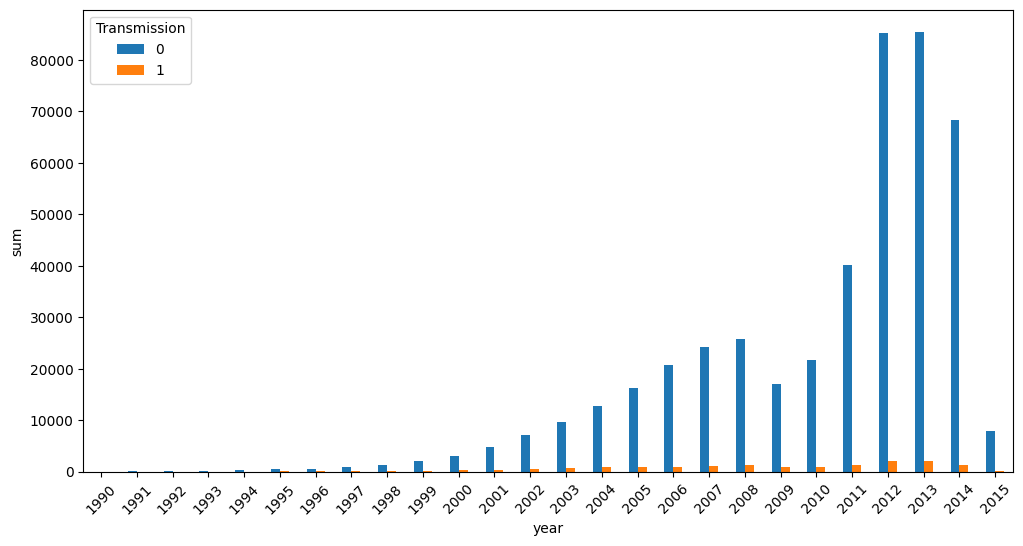

In [84]:
cont_t = (
    filled
    .groupby('year')['transmission']
    .value_counts()
    .unstack(fill_value=0)
)

cont_t

cont_t.plot(kind='bar', figsize=(12, 6))

plt.xlabel('year')
plt.ylabel('sum')
plt.legend(title='Transmission')
plt.xticks(rotation=45)
plt.show()

In [85]:
#now using a balanced model

model_t = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
model_t.fit(xt_train, yt_train)

pred_t = model_t.predict(xt_test)

In [86]:
prec_t = precision_score(yt_test, pred_t)
print("Precision:", prec_t)

Precision: 0.06019293387298013


In [87]:
acc_t = accuracy_score(yt_test, pred_t)
print("Accuracy:", acc_t)

Accuracy: 0.6589636373259937


the atemp to use logistic regressio leaded to very unstable results, even balancing resulted in bad precision and accuracy, thogth it was decided to fill NAN transmission with 0 (automatic)

In [140]:
df_mode = df_mode.drop(columns=['saledate'])
df_mode = df_mode.drop(columns=['mmr'])
df_mode.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,21500.0
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,21500.0
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),30000.0
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27750.0
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),67000.0


In [141]:
df_mode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  558837 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  sellingprice  558825 non-null  float64
dtypes: float64(3), int64(1), object(10)
memory usage: 59.7+ MB


In [142]:
le = LabelEncoder()

for col in df_mode.select_dtypes(include='object').columns:
    df_mode[col] = le.fit_transform(df_mode[col])

df_mode.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice
0,2015,24,658,998,36,1,403800,29,5.0,16639.0,43,1,7202,21500.0
1,2015,24,658,998,36,1,403792,29,5.0,9393.0,43,0,7202,21500.0
2,2014,3,9,283,37,1,507008,29,45.0,1331.0,33,1,4978,30000.0
3,2015,51,596,1399,37,1,546651,29,41.0,14282.0,43,1,13795,27750.0
4,2014,3,42,498,37,1,508041,29,43.0,2641.0,33,1,4978,67000.0


In [155]:
df_mode = df_mode.drop(columns=['seller'])
df_mode = df_mode.drop(columns=['vin'])
df_mode = df_mode.dropna()

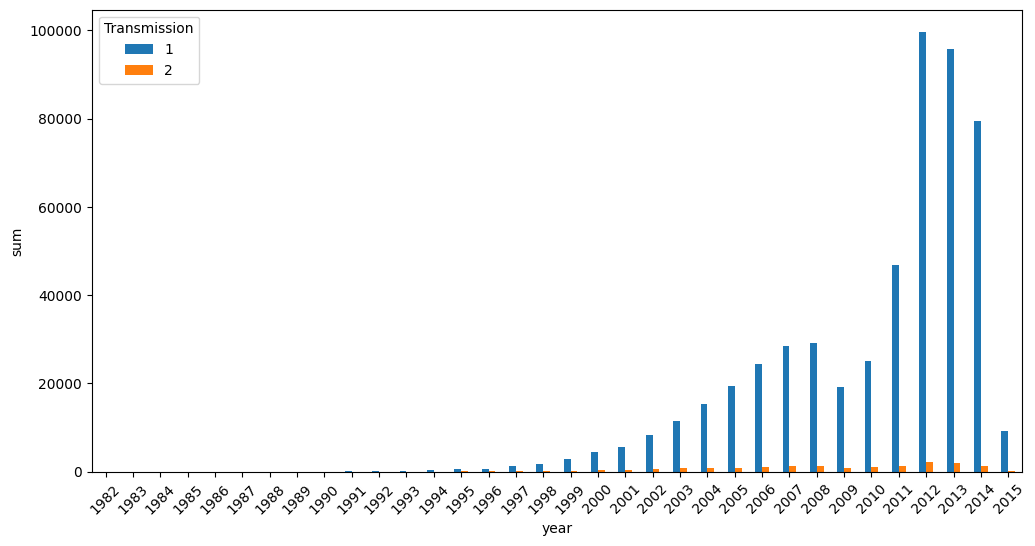

In [144]:
cont_t = (
    df_mode
    .groupby('year')['transmission']
    .value_counts()
    .unstack(fill_value=0)
)

cont_t

cont_t.plot(kind='bar', figsize=(12, 6))

plt.xlabel('year')
plt.ylabel('sum')
plt.legend(title='Transmission')
plt.xticks(rotation=45)
plt.show()

preparing the data to model traing


In [160]:
x_train, x_test, y_train, y_test = train_test_split(df_mode.drop('sellingprice', axis=1), df_mode['sellingprice'], test_size=0.2, random_state=42)

now developing a standard model with linear regressor

In [161]:
#linearregressor model

model_LR = LinearRegression()
model_LR.fit(x_train, y_train)

pred_LR = model_LR.predict(x_test)

In [162]:
r2_LR = r2_score(y_test, pred_LR)
print('r2',r2_LR)

r2 0.3982270834352163


In [163]:
mae_LR = mean_absolute_error(y_test, pred_LR)

print('MAE:', mae_LR)

MAE: 5193.508577767714


In [164]:
rmse_LR = np.sqrt(mean_squared_error(y_test, pred_LR))

print('RMSE:', rmse_LR)

RMSE: 7560.272870146679


In [165]:
metricas_LR = {
    'R2_LR': r2_LR,
    'MAE_LR': mae_LR,
    'RMSE_LR': rmse_LR
}

print(metricas_LR)

{'R2_LR': 0.3982270834352163, 'MAE_LR': 5193.508577767714, 'RMSE_LR': np.float64(7560.272870146679)}


evaluating light gbm

In [166]:
model_lgbm = LGBMRegressor()
model_lgbm.fit(x_train, y_train)

pred_lgbm = model_lgbm.predict(x_test)

r2_lgbm = r2_score(y_test, pred_lgbm)
print('r2',r2_lgbm)
mae_lgbm = mean_absolute_error(y_test, pred_lgbm)

print('MAE:', mae_lgbm)

rmse_lgbm = np.sqrt(mean_squared_error(y_test, pred_lgbm))

print('RMSE:', rmse_lgbm)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.086064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1063
[LightGBM] [Info] Number of data points in the train set: 437580, number of used features: 11
[LightGBM] [Info] Start training from score 13768.663534
r2 0.8840414269699691
MAE: 2064.810185821474
RMSE: 3318.7350558117037


In [167]:
metricas_LGBM = {
    'R2_LGBM': r2_lgbm ,
    'MAE_LGBM': mae_lgbm ,
    'RMSE_LGBM': rmse_lgbm
}

print(metricas_LGBM)

{'R2_LGBM': 0.8840414269699691, 'MAE_LGBM': 2064.810185821474, 'RMSE_LGBM': np.float64(3318.7350558117037)}


now evaluating xg_boost model

In [168]:
model_XGB = XGBRegressor()
model_XGB.fit(x_train, y_train)

pred_XGB = model_XGB.predict(x_test)

r2_XGB = r2_score(y_test, pred_XGB)
print('r2',r2_XGB)
mae_XGB = mean_absolute_error(y_test, pred_XGB)

print('MAE:', mae_XGB)

rmse_XGB = np.sqrt(mean_squared_error(y_test, pred_XGB))

print('RMSE:', rmse_XGB)


r2 0.9194986091543754
MAE: 1685.691276864215
RMSE: 2765.176412247319


In [169]:
metricas_XGB = {
    'R2_XGB': r2_XGB,
    'MAE_XGB': mae_XGB,
    'RMSE_XGB': rmse_XGB
}

print(metricas_XGB)

{'R2_XGB': 0.9194986091543754, 'MAE_XGB': 1685.691276864215, 'RMSE_XGB': np.float64(2765.176412247319)}


In [170]:
# Model evaluation metrics
df_metrics = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'LightGBM',
        'XGBoost'
    ],
    'R2': [
        0.4133184463528842,
        0.8994612746322919,
        0.9353043242665188
    ],
    'MAE': [
        5133.5579416853625,
        1935.320326552256,
        1549.8762381892304
    ],
    'RMSE': [
        7464.872052518015,
        3090.208900818161,
        2478.8986919474655
    ]
})

df_metrics

,Model,R2,MAE,RMSE
0,Linear Regression,0.413318,5133.557942,7464.872053
1,LightGBM,0.899461,1935.320327,3090.208901
2,XGBoost,0.935304,1549.876238,2478.898692


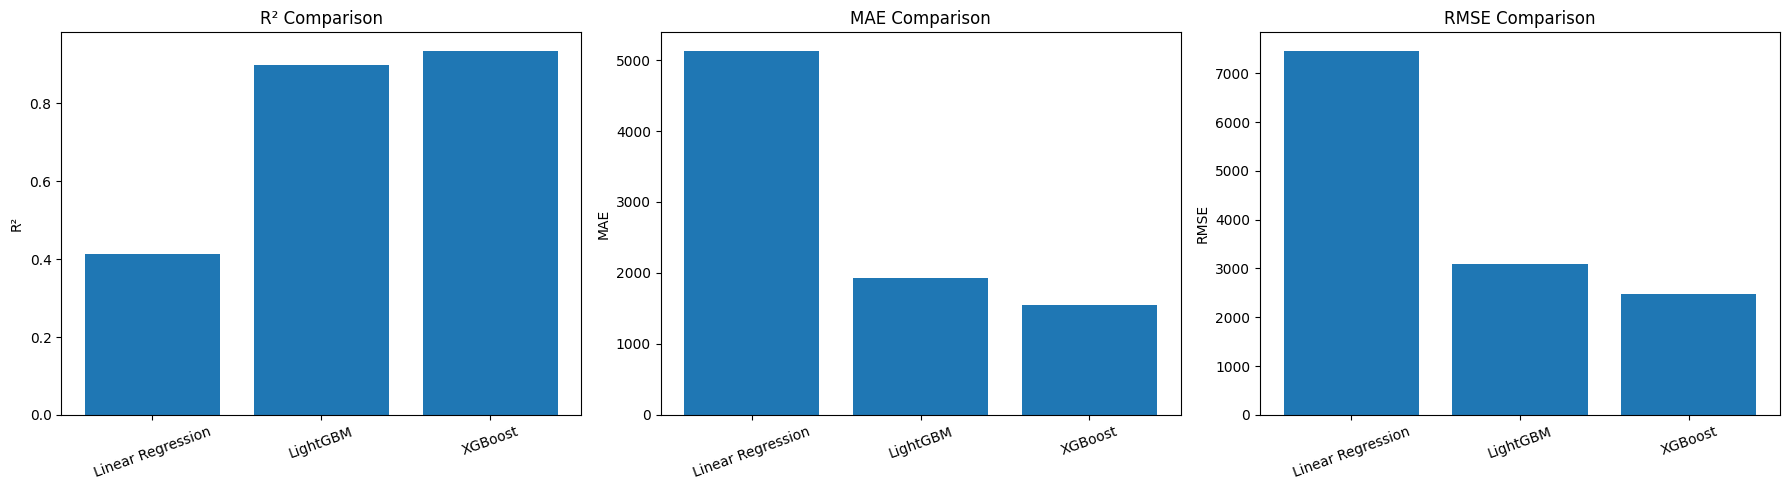

In [171]:
# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R²
axes[0].bar(df_metrics['Model'], df_metrics['R2'])
axes[0].set_title('R² Comparison')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=20)

# MAE
axes[1].bar(df_metrics['Model'], df_metrics['MAE'])
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=20)

# RMSE
axes[2].bar(df_metrics['Model'], df_metrics['RMSE'])
axes[2].set_title('RMSE Comparison')
axes[2].set_ylabel('RMSE')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

xgb presented the better results so it was submeted tio multvariaded optimization  

In [175]:


param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

model_XGB_opt = XGBRegressor(
    random_state=42
)

# Find indices where y_train is NaN or infinite
invalid_y_indices = y_train[y_train.isnull() | ~np.isfinite(y_train)].index

if not invalid_y_indices.empty:
    # Remove these rows from both x_train and y_train
    x_train = x_train.drop(invalid_y_indices)
    y_train = y_train.drop(invalid_y_indices)
    print(f"Removed {len(invalid_y_indices)} rows from x_train and y_train due to invalid y_train values.")

random_search = RandomizedSearchCV(
    estimator=model_XGB_opt,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='neg_root_mean_squared_error')

n_estimators      = 300
learning_rate     = 0.1
max_depth         = 8
min_child_weight  = 5
colsample_bytree   = 0.8

In [176]:
model_XGB_opt = random_search.best_estimator_

In [177]:
#saving model

import joblib
from google.colab import files

# Pega o melhor modelo encontrado pelo RandomizedSearchCV
model_XGB_opt = random_search.best_estimator_

# Salva o modelo
arquivo = 'model_XGB_opt.pkl'
joblib.dump(model_XGB_opt, arquivo)

# Baixa o arquivo para o computador
files.download(arquivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [178]:
pred_XGB_opt = model_XGB_opt.predict(x_test)

r2_XGB_opt = r2_score(y_test, pred_XGB_opt)
mae_XGB_opt = mean_absolute_error(y_test, pred_XGB_opt)
rmse_XGB_opt = np.sqrt(mean_squared_error(y_test, pred_XGB_opt))

print('R²:', r2_XGB_opt)
print('MAE:', mae_XGB_opt)
print('RMSE:', rmse_XGB_opt)

R²: 0.9474200818425236
MAE: 1322.9711932515684
RMSE: 2234.7611074150022


In [179]:
pred_train = model_XGB_opt.predict(x_train)

r2_train = r2_score(y_train, pred_train)
r2_test = r2_score(y_test, pred_XGB_opt)

print('R² treino:', r2_train)
print('R² teste:', r2_test)

R² treino: 0.9589324284357859
R² teste: 0.9474200818425236


now, the model needs to be validated

In [180]:
# 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for run, (train_idx, val_idx) in enumerate(kf.split(x_train), 1):

    # Split data
    X_train_fold = x_train.iloc[train_idx]
    X_val_fold = x_train.iloc[val_idx]

    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    # Clone optimized model
    model_fold = clone(model_XGB_opt)

    # Train
    model_fold.fit(X_train_fold, y_train_fold)

    # Predictions
    pred_fold = model_fold.predict(X_val_fold)

    # Metrics
    r2 = r2_score(y_val_fold, pred_fold)
    mae = mean_absolute_error(y_val_fold, pred_fold)
    rmse = np.sqrt(mean_squared_error(y_val_fold, pred_fold))

    # Store results
    results.append({
        'Run': run,
        'R²': r2,
        'MAE': mae,
        'RMSE': rmse
    })

# DataFrame with individual results
df_cv = pd.DataFrame(results)

# Add mean row
df_cv.loc['Mean'] = [
    'Mean',
    df_cv['R²'].mean(),
    df_cv['MAE'].mean(),
    df_cv['RMSE'].mean()
]

df_cv

,Run,R²,MAE,RMSE
0,1,0.947020,1331.176567,2247.809281
1,2,0.947257,1328.969537,2229.326612
2,3,0.945280,1331.020613,2280.076109
3,4,0.942887,1333.314284,2328.145324
4,5,0.945935,1340.917957,2273.926954
Mean,Mean,0.945676,1333.079792,2271.856856


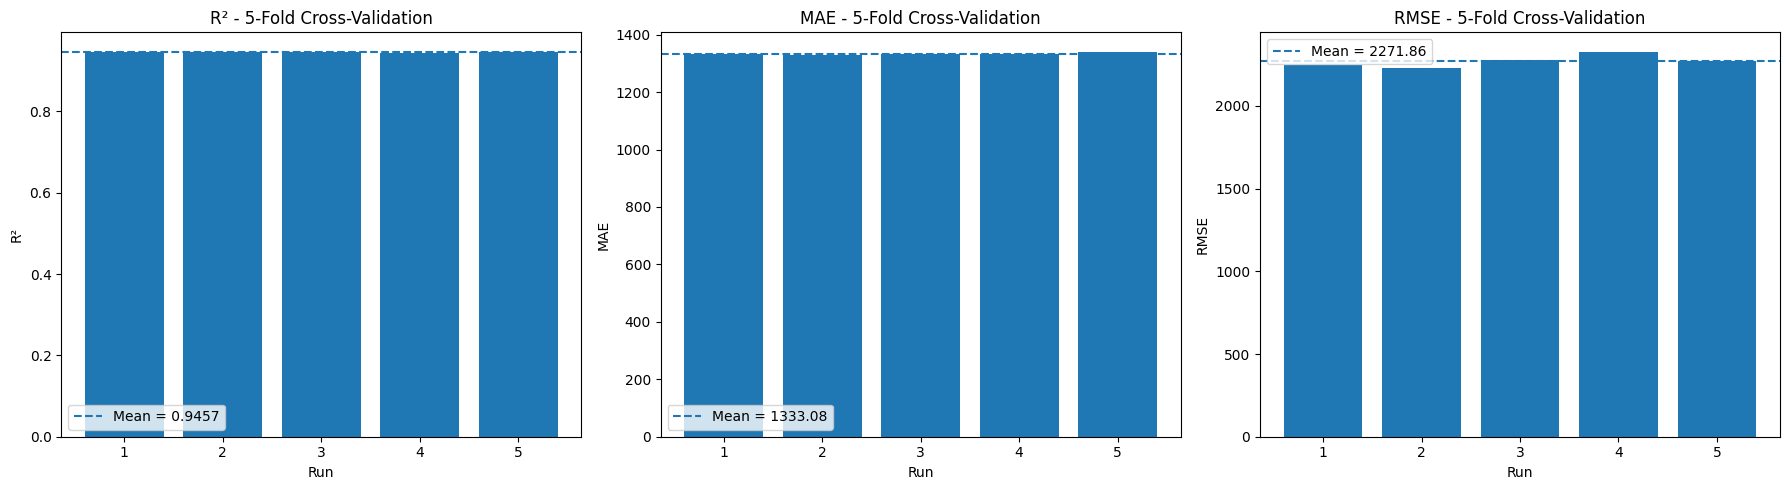

In [183]:

# Remove the Mean row for plotting individual runs
df_plot = df_cv[df_cv['Run'] != 'Mean'].copy()

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R²
axes[0].bar(df_plot['Run'].astype(str), df_plot['R²'])
axes[0].axhline(
    df_cv.loc['Mean', 'R²'],
    linestyle='--',
    label=f"Mean = {df_cv.loc['Mean', 'R²']:.4f}"
)
axes[0].set_title('R² - 5-Fold Cross-Validation')
axes[0].set_xlabel('Run')
axes[0].set_ylabel('R²')
axes[0].legend()

# MAE
axes[1].bar(df_plot['Run'].astype(str), df_plot['MAE'])
axes[1].axhline(
    df_cv.loc['Mean', 'MAE'],
    linestyle='--',
    label=f"Mean = {df_cv.loc['Mean', 'MAE']:.2f}"
)
axes[1].set_title('MAE - 5-Fold Cross-Validation')
axes[1].set_xlabel('Run')
axes[1].set_ylabel('MAE')
axes[1].legend()

# RMSE
axes[2].bar(df_plot['Run'].astype(str), df_plot['RMSE'])
axes[2].axhline(
    df_cv.loc['Mean', 'RMSE'],
    linestyle='--',
    label=f"Mean = {df_cv.loc['Mean', 'RMSE']:.2f}"
)
axes[2].set_title('RMSE - 5-Fold Cross-Validation')
axes[2].set_xlabel('Run')
axes[2].set_ylabel('RMSE')
axes[2].legend()

plt.tight_layout()
plt.show()

         Feature  Importance
0           year    0.267358
1           make    0.171247
8       odometer    0.146902
4           body    0.144174
3           trim    0.087303
2          model    0.080224
7      condition    0.056622
10      interior    0.018444
5   transmission    0.011747
9          color    0.008286
6          state    0.007693


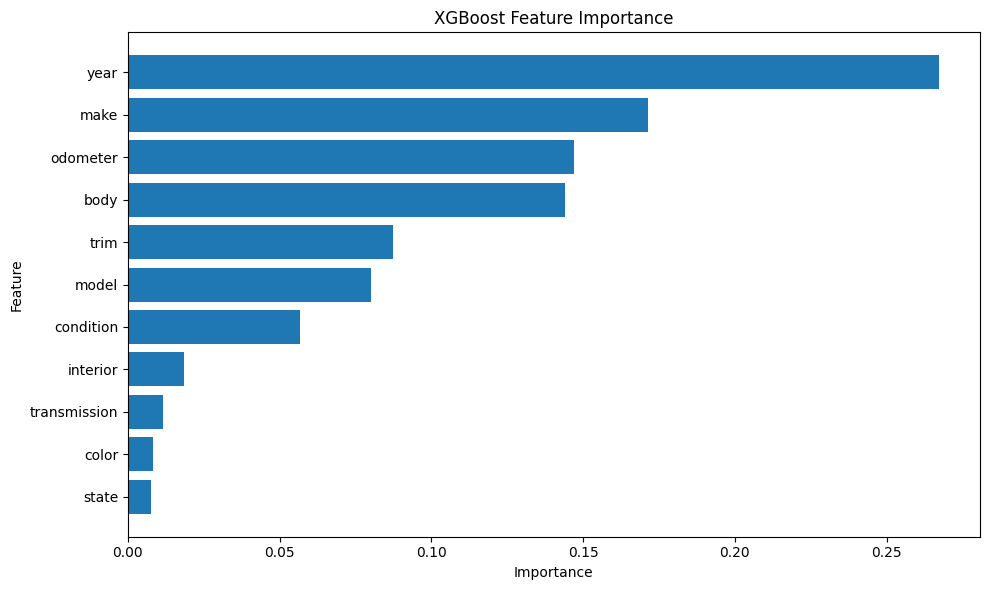

In [184]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model_XGB_opt.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display
print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()